# 工廠零件分類 — Baseline 訓練

**目的**：用手刻 CNN（HW9 風格 + skip connection）驗證 Blender 合成資料集是否可訓練。

**不是最終模型** — 期末組員會用更強的架構。這個 notebook 只是 Harrison 端評估資料集品質。

**資料**：4 類零件 × 144 張 = 576 張 RGBA PNG，256×256，HDRI 打光，透明背景

**模型**：3 層 Conv（含 1 個 skip connection）+ 2 層 FC，輸入 resize 到 64×64

In [1]:
# ─── Setup ───
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# 固定隨機種子確保可復現
SEED = 30
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
  GPU: NVIDIA GeForce RTX 4060


In [2]:
# ─── 資料載入 ───
# raw/ 目錄結構是 ImageFolder 相容：output/dataset/raw/{class_name}/*.png
DATA_ROOT = r'D:\Harrison\中山\大四下\深度學習期末報告\output\dataset\raw'
IMG_SIZE = 64  # 對應 HW9 32×32 風格，但稍大保留更多特徵

# Transforms：RGBA → RGB（合成黑底）→ Resize → ToTensor → Normalize
data_transforms = transforms.Compose([
    transforms.Lambda(lambda img: img.convert('RGB')),  # 砍掉 alpha，透明處變黑
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

full_dataset = datasets.ImageFolder(DATA_ROOT, transform=data_transforms)

class_names = full_dataset.classes
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')
print(f'Total samples: {len(full_dataset)}')

# 60/20/20 random split (seeded)
n_total = len(full_dataset)
n_train = int(0.6 * n_total)
n_val   = int(0.2 * n_total)
n_test  = n_total - n_train - n_val
generator = torch.Generator().manual_seed(SEED)
train_set, val_set, test_set = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)
print(f'Train / Val / Test: {n_train} / {n_val} / {n_test}')

BATCH_SIZE = 32
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

Classes (4): ['flange_nut', 'hex_nut', 'pan_head', 'socket_head']
Total samples: 576
Train / Val / Test: 345 / 115 / 116


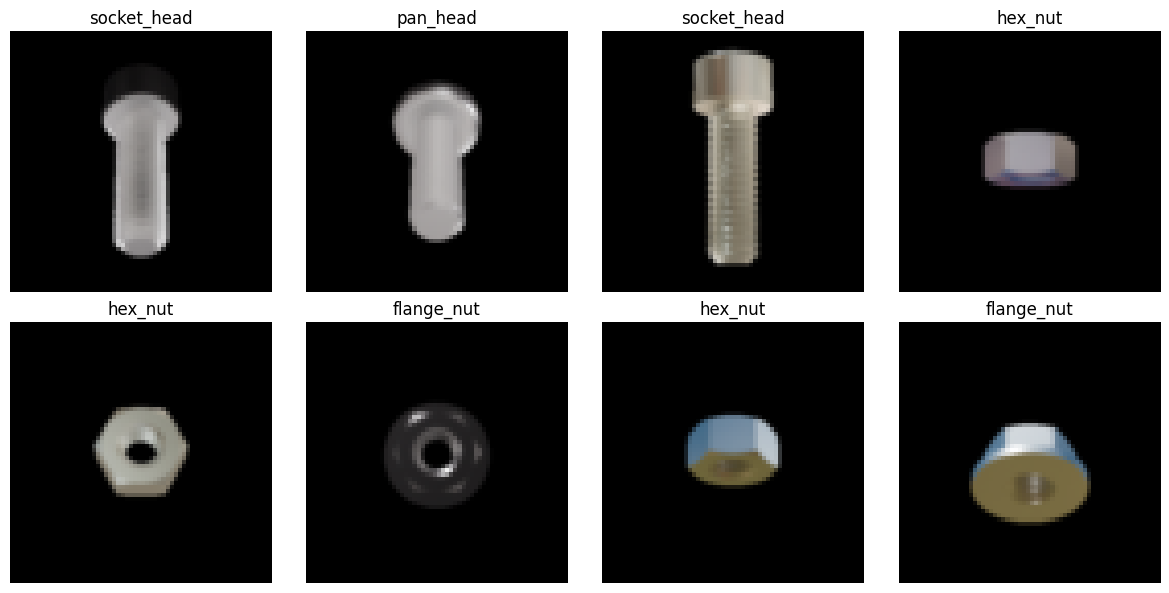

In [3]:
# ─── 視覺檢查：看幾張訓練圖確認資料正常 ───
def unnormalize(img_tensor):
    img = img_tensor.clone()
    img = img * 0.5 + 0.5  # 反 normalize
    return img.clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = unnormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# ─── 模型：手刻 CNN with skip connection（延續 HW9 風格）───
class PartsCNN(nn.Module):
    """
    輸入：3 × 64 × 64
    架構：3 層 Conv（中間 1 個 skip connection）+ 2 層 FC
    
    Conv1 (3→32, 3×3)  → ReLU → MaxPool2  →  32×32×32
    Conv2 (32→16, 3×3) → ReLU → MaxPool2  →  16×16×16
    Conv3 (16→16, 3×3) → ReLU + skip → MaxPool2  →  16×8×8
    Flatten → FC1 (1024→64) → ReLU → FC2 (64→4)
    """
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(16 * 8 * 8, 64)
        self.fc2   = nn.Linear(64, num_classes)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)   # → 32×32×32
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2) # → 16×16×16
        identity = out
        out = F.max_pool2d(torch.relu(self.conv3(out)) + identity, 2)  # skip + → 16×8×8
        out = out.view(out.size(0), -1)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = PartsCNN(num_classes=num_classes).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {n_params:,}')
print(model)

Model parameters: 73,700
PartsCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)


In [5]:
# ─── Training & Validation loops（HW9 風格）───
def training_loop(model, optimizer, train_loader, val_loader, n_epochs):
    loss_fn = nn.CrossEntropyLoss()
    train_losses, val_accs = [], []

    for epoch in range(n_epochs):
        model.train()
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            predictions = model(imgs)
            loss = loss_fn(predictions, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()

        avg_loss = loss_train / len(train_loader)
        val_acc  = evaluate(model, val_loader, verbose=False)
        train_losses.append(avg_loss)
        val_accs.append(val_acc)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1:3d}/{n_epochs} | train_loss={avg_loss:.4f} | val_acc={val_acc*100:.2f}%')
    return train_losses, val_accs

def evaluate(model, loader, verbose=True):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            _, predicted = torch.max(preds, dim=1)
            total   += labels.size(0)
            correct += int((predicted == labels).sum())
    acc = correct / total
    if verbose:
        print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    return acc

In [6]:
# ─── 訓練 ───
LEARNING_RATE = 0.01
EPOCHS = 50

model = PartsCNN(num_classes=num_classes).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

train_losses, val_accs = training_loop(model, optimizer, train_loader, val_loader, EPOCHS)

Epoch   1/50 | train_loss=1.3853 | val_acc=18.26%
Epoch   5/50 | train_loss=0.8469 | val_acc=44.35%
Epoch  10/50 | train_loss=0.4210 | val_acc=73.04%
Epoch  15/50 | train_loss=0.2158 | val_acc=94.78%
Epoch  20/50 | train_loss=0.1174 | val_acc=93.91%
Epoch  25/50 | train_loss=0.0289 | val_acc=98.26%
Epoch  30/50 | train_loss=0.0039 | val_acc=99.13%
Epoch  35/50 | train_loss=0.0022 | val_acc=100.00%
Epoch  40/50 | train_loss=0.0015 | val_acc=100.00%
Epoch  45/50 | train_loss=0.0011 | val_acc=100.00%
Epoch  50/50 | train_loss=0.0009 | val_acc=100.00%


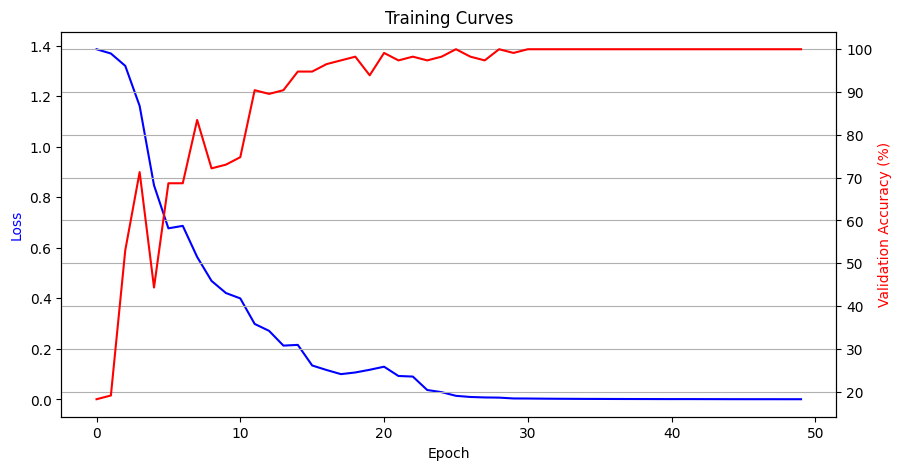

In [7]:
# ─── Loss / Accuracy 曲線 ───
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(train_losses, 'b-', label='Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss', color='b')
ax2 = ax1.twinx()
ax2.plot([a*100 for a in val_accs], 'r-', label='Val Acc (%)')
ax2.set_ylabel('Validation Accuracy (%)', color='r')
plt.title('Training Curves')
plt.grid(True)
plt.show()

Test set:
Accuracy: 1.0000 (100.00%)


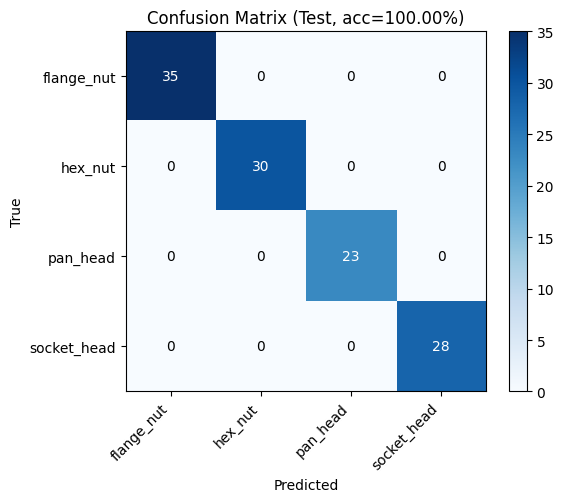

In [8]:
# ─── Test set 最終評估 ───
print('Test set:')
test_acc = evaluate(model, test_loader)

# Confusion matrix
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (Test, acc={test_acc*100:.2f}%)')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im); plt.tight_layout(); plt.show()

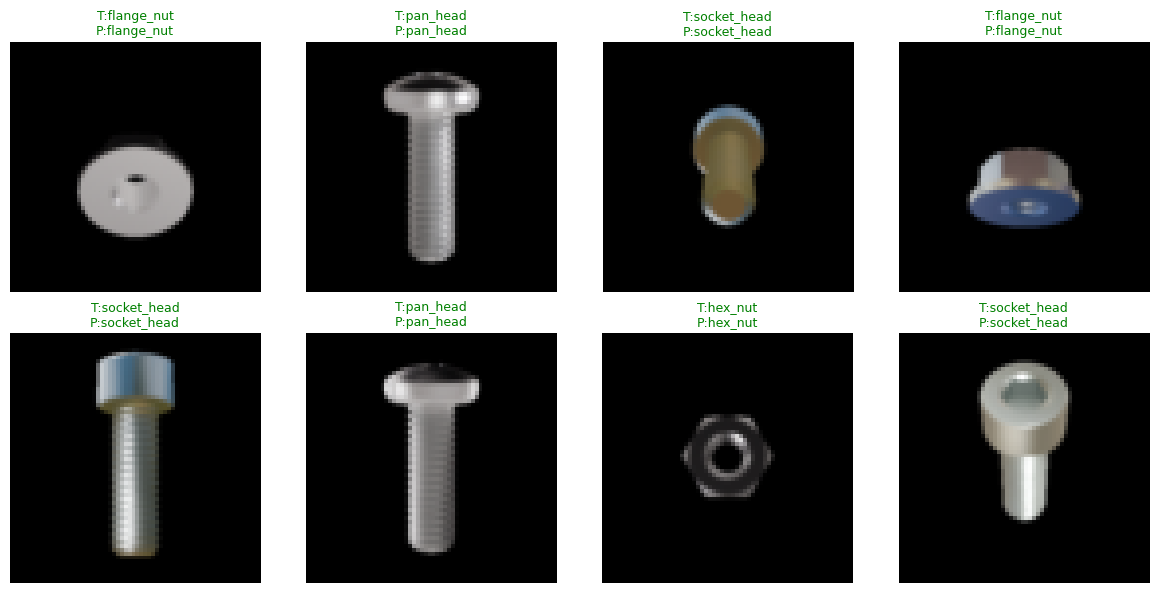

In [9]:
# ─── 樣本預測視覺化 ───
imgs, labels = next(iter(test_loader))
imgs_dev = imgs.to(device)
with torch.no_grad():
    preds = model(imgs_dev).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = unnormalize(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    t = class_names[labels[i]]
    p = class_names[preds[i]]
    color = 'green' if t == p else 'red'
    ax.set_title(f'T:{t}\nP:{p}', color=color, fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()